# Pyreflect Reflectivity Pipeline Example

This notebook demonstrates the example workflow with clearer, annotated steps. It shows how to go from neutron reflectivity (NR) curves to scattering length density (SLD) profiles using `pyreflect`.


## 1. Environment setup

Use the following cells to make sure PyTorch and pyreflect are available. Installation is commented out so you can enable it only if needed.


In [ ]:
# Uncomment if ipykernel is needed in this environment. Skip for windows.

!curl -fsSL https://raw.githubusercontent.com/williamQyq/pyreflect/main/setup.sh | bash

### 1.1 Install `pyreflect`

`Note`: Install may takes some times and restart Kernel after installation

In [ ]:
# Uncomment if pyreflect is not installed in this environment.
# Installation may takes some times
!pip install pyreflect-nr==1.4.5

In [2]:
!pip show pyreflect-nr

Name: pyreflect-nr
Version: 1.4.5
Summary: The package tool for neutron reflectivity analysis
Home-page: https://github.com/williamQyq/pyreflect
Author: Yuqing Qiao
Author-email: qiao.yuqi@northeastern.edu
License-Expression: MIT
Location: c:\users\qyqfi\miniconda3\envs\pyreflect\lib\site-packages
Requires: allpairspy, llvmlite, numba, numpy, opencv-python, pandas, pyyaml, refl1d, refnx, scikit-learn, scipy, seaborn, torch, tqdm, typer
Required-by: 


In [3]:
import platform, sys, importlib

def safe_version(pkg):
    try:
        module = importlib.import_module(pkg)
        return getattr(module, "__version__", "unknown")
    except ModuleNotFoundError:
        return "not installed"

print(f"Python: {sys.version.split()[0]} ({platform.system()} {platform.release()})")
print(f"PyTorch: {safe_version('torch')}")

try:
    import torch
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("CUDA device:", torch.cuda.get_device_name(0))
except ModuleNotFoundError:
    pass

Python: 3.10.19 (Windows 10)
PyTorch: 2.5.1+cu121
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3070 Ti


## 2. Paths and data overview

We keep all paths together for clarity. The repo already ships generated train/test splits and a pretrained model so you can run inference quickly.


In [4]:
from pathlib import Path
import numpy as np
from pprint import pprint

ROOT = Path(".")

TRAIN_SLD = ROOT / "data/curves/sld-5-train-150k.npy"
TRAIN_NR = ROOT / "data/curves/nr-5-train-150k.npy"

TEST_NR = ROOT / "data/curves/X_test_5_layers.npy"
TEST_SLD = ROOT / "data/curves/y_test_5_layers.npy"
PRETRAINED_MODEL = ROOT / "data/trained_nr_sld_model_dropout_no_sigmoid_150k.pth"

NORMALIZATION_STAT = ROOT / "data/normalization_stat.npy"

for path in [TRAIN_NR, TRAIN_SLD, TEST_NR, TEST_SLD, NORMALIZATION_STAT]:
    assert path.exists(), f"Missing file: {path}"
print("All expected files are present.")

All expected files are present.


## 2.1 Configuration Overview
We load and inspect the NR → SLD pipeline configuration:

Load settings.yml, then override the paths and hyperparameters to match the data above. Keep epochs small for a quick demo;

In [ ]:
# import sys
# !{sys.executable} -m pyreflect init --force

In [5]:
import pyreflect
from pyreflect.config import load_config
from pyreflect.input import NRSLDDataProcessor
import pyreflect.pipelines.reflectivity_pipeline as workflow
from pprint import pprint
import numpy as np

root = "./"
config = pyreflect.config.load_config(root)

pprint(config['nr_predict_sld'])

{'file': {'nr_train': 'data/curves/nr_train.npy',
          'sld_train': 'data/curves/sld_train.npy'},
 'models': {'batch_size': 32,
            'dropout': 0.5,
            'epochs': 10,
            'layers': 12,
            'model': 'data/trained_nr_sld_model.pth',
            'normalization_stats': 'data/normalization_stat.npy',
            'num_curves': 50000,
            'num_film_layers': 5}}


## 3. Dataset Preparation
- We load pre-generated synthetic datasets (already shuffled):
    - NR curves: shape (N, 2, 308) → (Q, R)
    - SLD profiles: shape (N, 2, 900) → (z, ρ)

In [6]:
dproc = NRSLDDataProcessor(TRAIN_NR,TRAIN_SLD).load_data()
dproc._nr_arr.shape, dproc._sld_arr.shape

((150000, 2, 308), (150000, 2, 900))

## 4. Model Architecture & Training
### 4.1 Training Configuration

In [7]:
model_config = config["nr_predict_sld"]["models"]
# the # of material layers
model_config["num_film_layers"] = 5
model_config["dropout"] = 0.3
model_config["epochs"] = 5
model_config["model"]=PRETRAINED_MODEL
# cnn model layers
model_config["layers"]=12
model_config["normalization_stats"] = NORMALIZATION_STAT


file_config = config["nr_predict_sld"]["file"]
# training X
file_config["nr_train"] = TRAIN_NR
# training y
file_config["sld_train"] = TRAIN_SLD


from pyreflect.models.config import NRSLDModelTrainerParams
# Hyperparameters for training
trainer_params = NRSLDModelTrainerParams(root,_config = config)

### 4.2 Prepare a lightweight training set
The full training split is large; to keep the example snappy we take a small slice. Adjust train_slice as needed.

In [8]:
import pyreflect.pipelines.reflectivity_pipeline as workflow

# Use the NRSLDDataProcessor to handle pre-processing
X_train, y_train = workflow.preprocess(dproc,trainer_params.normalization_stats)

## 5. Train or load a model

Set `use_pretrained=True` to skip training and use the bundled weights. Set it to `False` to run a short training session with the sliced data.

The trained model is automatically saved for reuse. The save model path will be `PRETRAINED_MODEL`

In [9]:
use_pretrained = False

pipeline = workflow.ReflectivityPipeline(None, trainer_params)

if use_pretrained:
    model = pipeline.load_model(str(PRETRAINED_MODEL))
else:
    # training model
    model = workflow.train_nr_predict_sld_model(X_train, y_train, trainer_params, auto_save=True)

norm_stats = workflow.load_normalization_stat(str(NORMALIZATION_STAT))


Epoch 1/5 - Train Loss: 0.010865, Validation Loss: 0.004588
Epoch 2/5 - Train Loss: 0.004126, Validation Loss: 0.002092
Epoch 3/5 - Train Loss: 0.002666, Validation Loss: 0.001677
Epoch 4/5 - Train Loss: 0.002098, Validation Loss: 0.001291
Epoch 5/5 - Train Loss: 0.001846, Validation Loss: 0.001348
NR predict SLD trained CNN model saved at: data\trained_nr_sld_model_dropout_no_sigmoid_150k.pth


## 6. Run inference on a test batch (Skip for Experimental Data Inference)

We take a handful of test NR curves and predict their SLD profiles.


In [ ]:
# test_batch = 10
# test_proc = NRSLDDataProcessor(TEST_NR, TEST_SLD).load_data()
# nr_batch = test_proc._nr_arr[:test_batch]
# true_sld = test_proc._sld_arr[:test_batch]
# 
# y_pred = pipeline.predict_sld(nr_batch, norm_stats, model)
# print("Predictions shape:", np.asarray(y_pred).shape)

## 7. Helper Function (Optional) — for Experimental Data

The experimental SLD–depth profile must be flipped so that it is oriented from the silicon substrate toward the air interface, ensuring consistency with the model’s prediction format.
Belows are helper function to do the flip and align points.

In [10]:
from pyreflect.pipelines.helper import reverse_y_order, find_substrate_critical_idx, align_points

# usage:
# Flip SLD y from left to right, substrate to air direction
# reverse_y_order(sld_array)

# Align B to A
# aligned_arr = align_points(a,b)

> [!IMPORTANT]
> When loading experimental data, **flip the SLD profile starting point from base to air** before proceeding. Ensure the shape is (2,L) instead of (L,2).

---

### 7.1 Load Experimental Data

In [ ]:
import os
import glob
import numpy as np

EXPT_FOLDER = "data/curves/exp-data" # Enter the relative path for experimental data
nr_files = sorted(glob.glob(os.path.join(EXPT_FOLDER, "np_*.npy"))) # assuming NR data file start with "np_*"
sld_files = sorted(glob.glob(os.path.join(EXPT_FOLDER, "sld_*.npy")))

In [11]:
test_batch = min(10, len(nr_files))

TARGET_LEN = 900

nr_batch = []
true_sld = []

for i in range(test_batch):
    nr = np.load(nr_files[i])      # (308, 2)
    sld = np.load(sld_files[i])   # (L, 2)

    # transpose NR → (2, 308)
    nr = nr.T

    # transpose SLD → (2, L)
    sld = sld.T

    # -------- Interpolate SLD to 900 --------
    L = sld.shape[1]
    x_old = np.linspace(0, 1, L)
    x_new = np.linspace(0, 1, TARGET_LEN)

    sld_interp = np.zeros((2, TARGET_LEN))

    for ch in range(2):
        sld_interp[ch] = np.interp(x_new, x_old, sld[ch])

    nr_batch.append(nr)
    sld_interp = reverse_y_order(sld_interp)
    sld_interp[0] = sld_interp[0] - sld_interp[0].min()

    true_sld.append(sld_interp) 

nr_batch = np.array(nr_batch)        # (B, 2, 308)
true_sld = np.array(true_sld)        # (B, 2, 900)

y_pred = pipeline.predict_sld(nr_batch, norm_stats, model)

print("NR batch shape:", nr_batch.shape)
print("True SLD shape:", true_sld.shape)
print("Predictions shape:", np.asarray(y_pred).shape)

Predicted SLD shape: (7, 2, 900)
NR batch shape: (7, 2, 308)
True SLD shape: (7, 2, 900)
Predictions shape: (7, 2, 900)


## 8. Compute Neutron Reflectivity (NR) from SLD

This section defines a helper function to compute neutron reflectivity directly from the predicted SLD profile, enabling comparison with the ground-truth reflectivity to verify the training result.


In [12]:
import numpy as np
import pyreflect
from pyreflect.pipelines import compute_nr_from_sld

computed_nr = []

for i in range(test_batch):
    profile = np.asarray(y_pred[i])

    Q,R = compute_nr_from_sld(profile)
    # Stack Q and R → (2, nQ)
    QR = np.stack([Q, R], axis=0)
    computed_nr.append(QR)

# Stack samples → (10, 2, nQ)
computed_nr = np.stack(computed_nr)


## 9. Visualization: Prediction vs GroundTruth -- NR & SLD Side-by-Side

- Left: Experimental NR vs NR recomputed from predicted SLD

- Right: Ground-truth SLD vs predicted SLD (with/without dropout)

In [13]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["font.family"] = "DejaVu Sans"

def plot_experiment_results(
    expt_nr_data,
    expt_sld_data=None,
    computed_nr_data=None,
    computed_nr_dropout_data=None,
    predicted_sld_data=None,
    predicted_sld_dropout_data=None
):
    mpl.rcParams.update({
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "lines.linewidth": 1.3,
        "figure.dpi": 300,
    })

    fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.6))

    # --- Left: Reflectivity (NR) ---
    axes[0].plot(expt_nr_data[0], expt_nr_data[1],
                 color="black", alpha=0.8, linestyle="-", linewidth=2,
                 label="GroundTruth")

    if computed_nr_data is not None:
        axes[0].plot(computed_nr_data[0], computed_nr_data[1],
                     color="red", linestyle="--", label="No Dropout")

    if computed_nr_dropout_data is not None:
        axes[0].plot(computed_nr_dropout_data[0], computed_nr_dropout_data[1],
                     color="blue", linestyle="--", label="Dropout")

    axes[0].set_xlabel(r"$q$ (Å$^{-1}$)")       # italic lowercase q
    axes[0].set_ylabel("NR")
    axes[0].set_yscale("log")
    axes[0].set_xscale("log")                     # log x-axis like the image
    axes[0].xaxis.set_major_formatter(mpl.ticker.LogFormatterMathtext())
    axes[0].legend(frameon=False, loc="lower left", handlelength=2.5)


    # --- Right: SLD Profiles ---
    if expt_sld_data is not None:
        axes[1].plot(expt_sld_data[0], expt_sld_data[1],
                     color="black", alpha=0.8, linestyle="-", linewidth=2,
                     label="Manual Fit")

    if predicted_sld_data is not None:
        axes[1].plot(predicted_sld_data[0], predicted_sld_data[1],
                     color="red", linestyle=":", label="No Dropout")

    if predicted_sld_dropout_data is not None:
        axes[1].plot(predicted_sld_dropout_data[0], predicted_sld_dropout_data[1],
                     color="blue", linestyle="--", label="Dropout")

    axes[1].set_xlabel(r"$z$ (Å)")               # italic z, not "Depth"
    axes[1].set_ylabel("SLD (×10⁻⁶ Å⁻²)")
    axes[1].legend(frameon=False, loc="lower left", handlelength=2.5)


    for ax in axes:
        ax.set_title("")
        ax.tick_params(direction="in", length=2.5)

    plt.tight_layout(pad=1.0, w_pad=1.4)
    
    plt.show()
    return fig

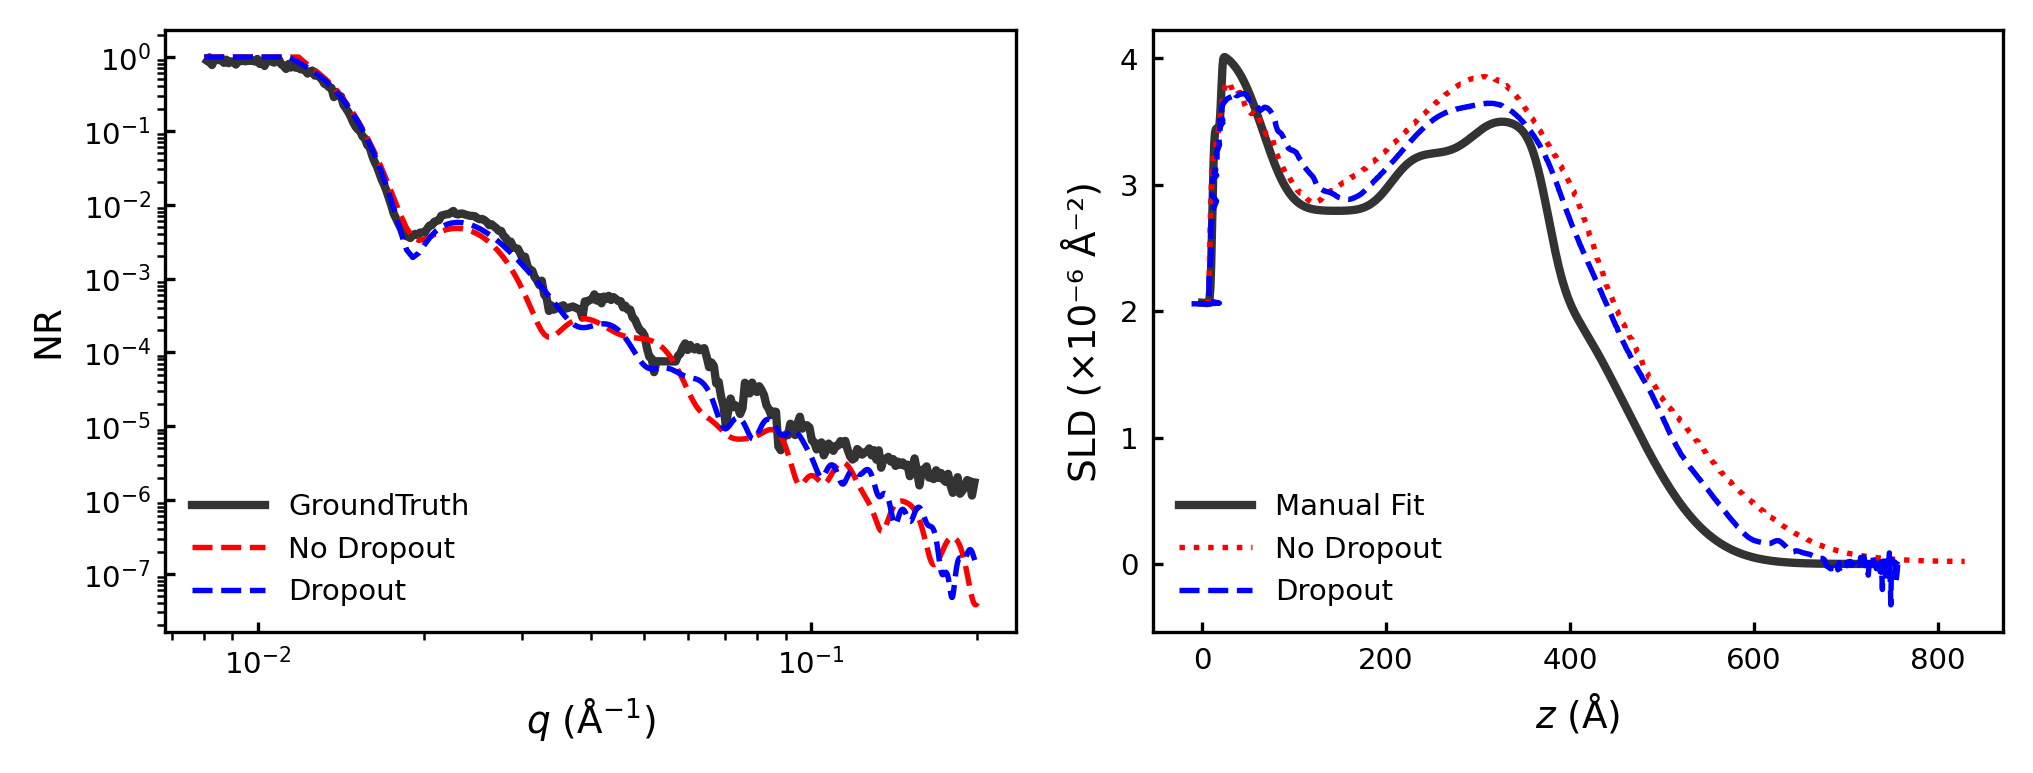

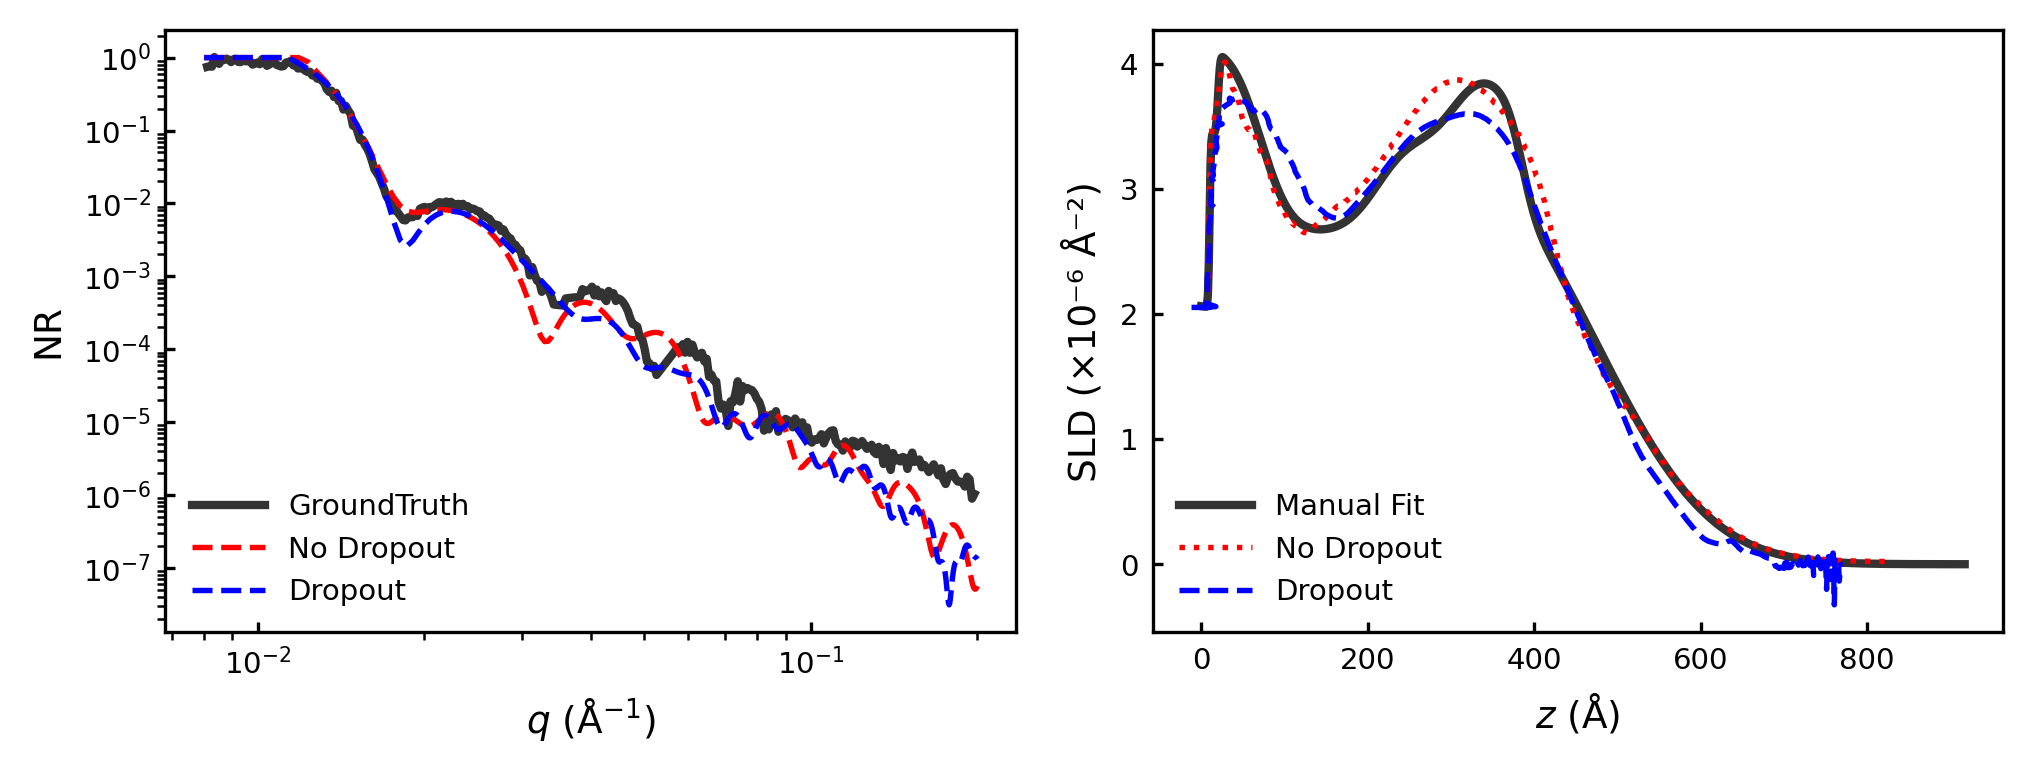

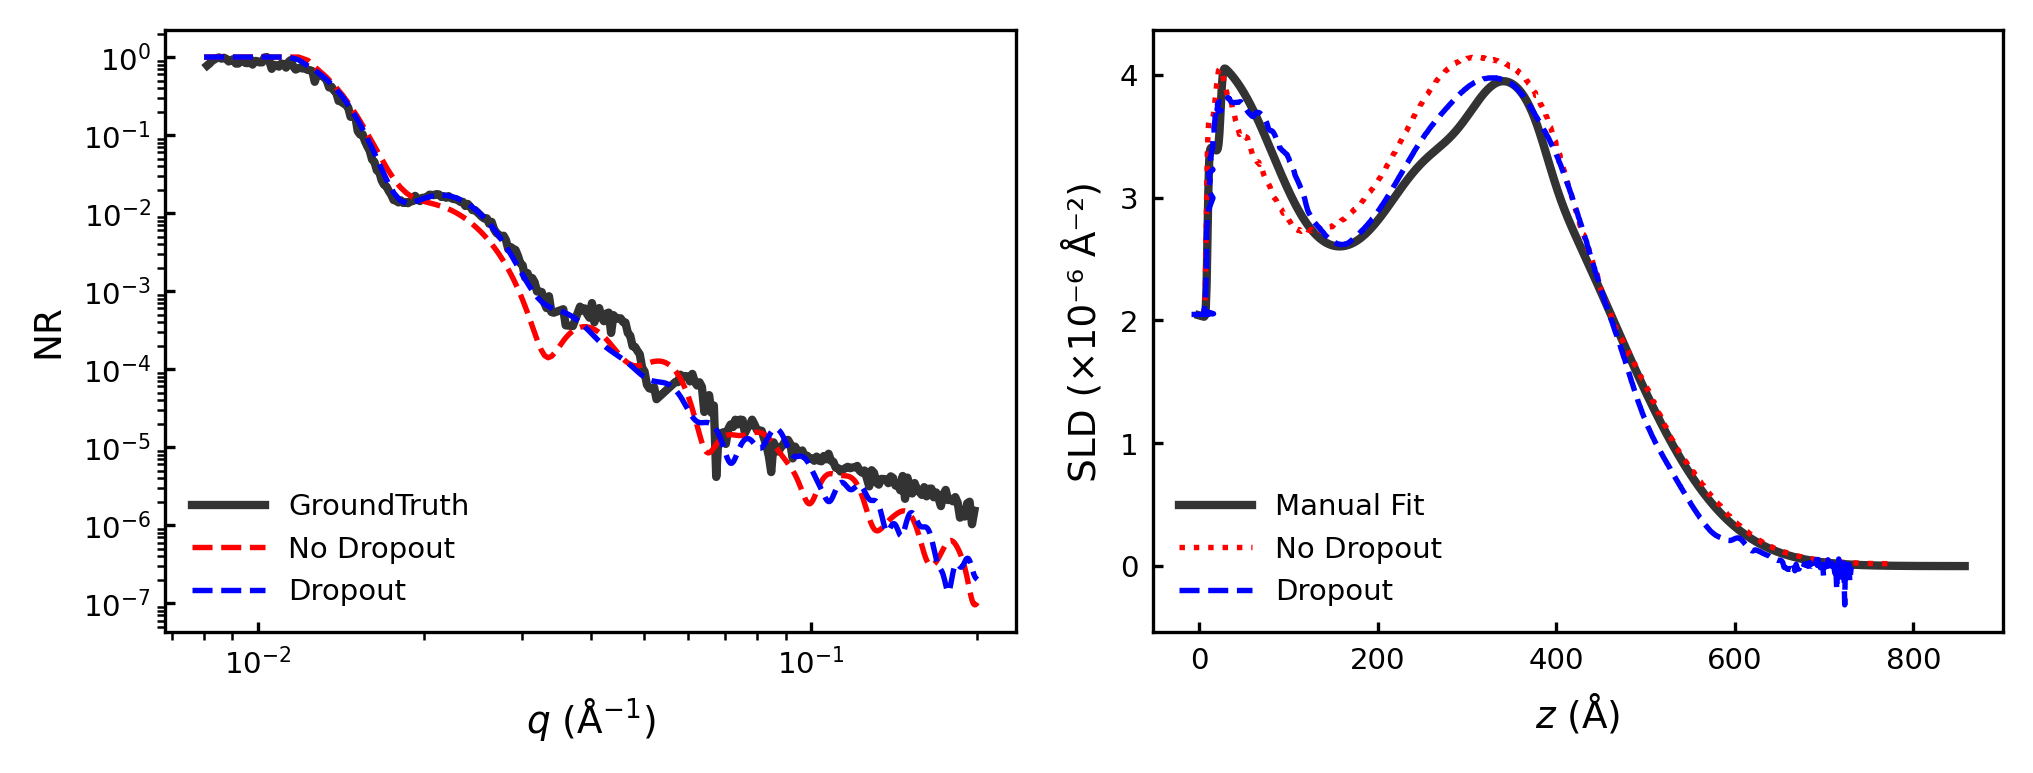

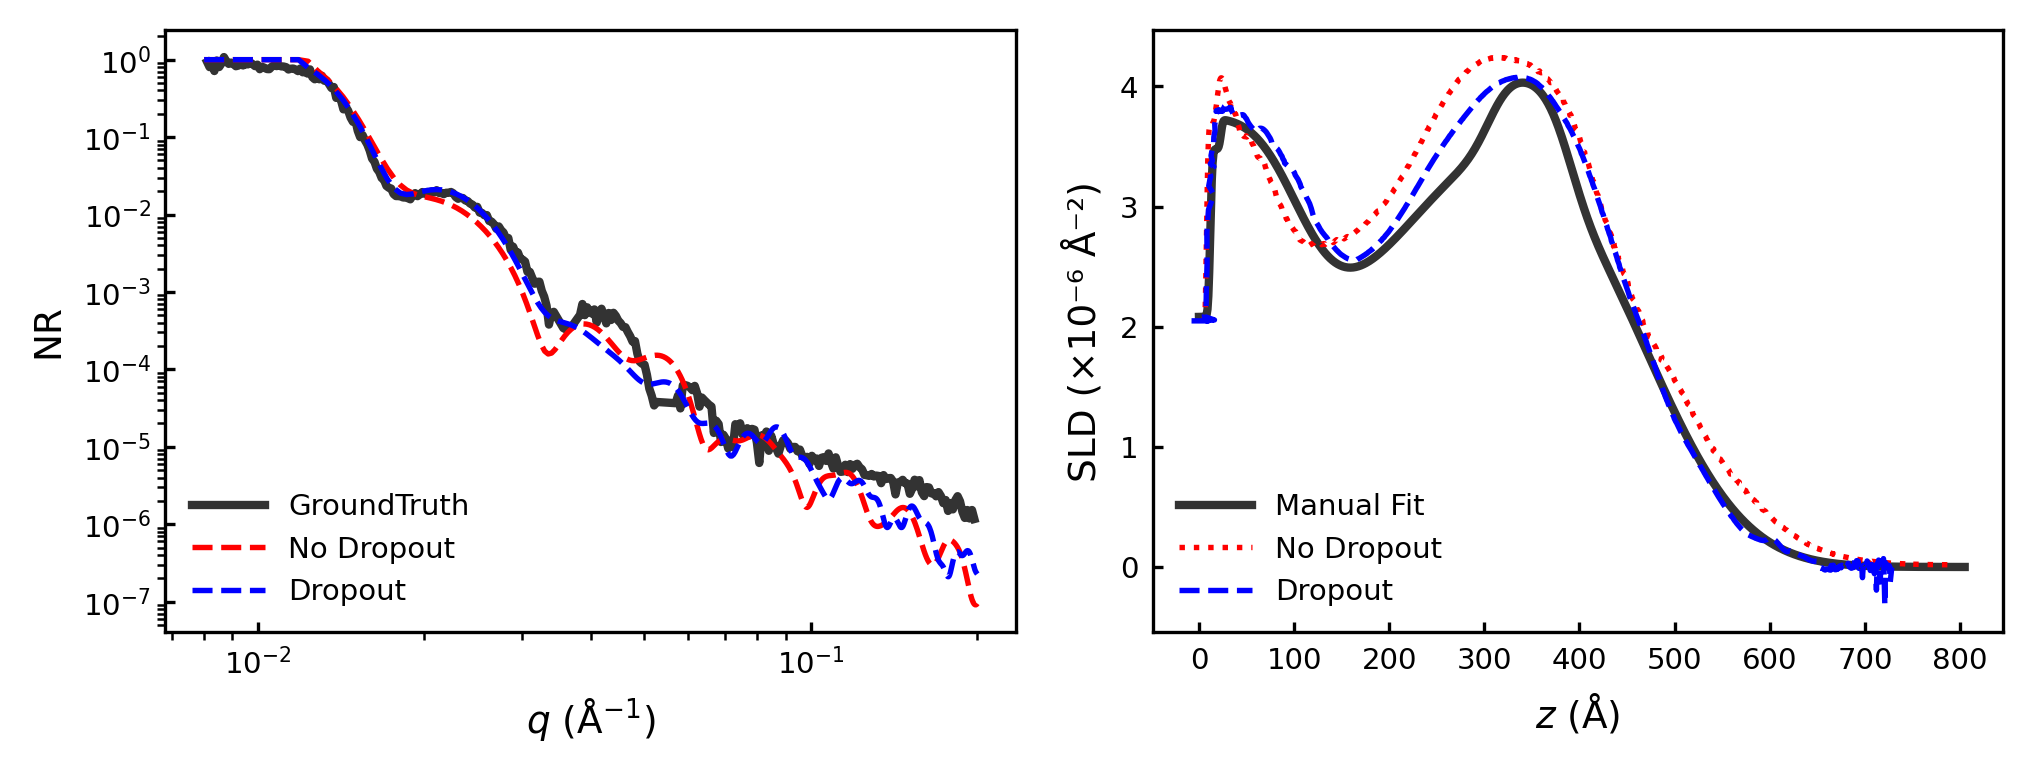

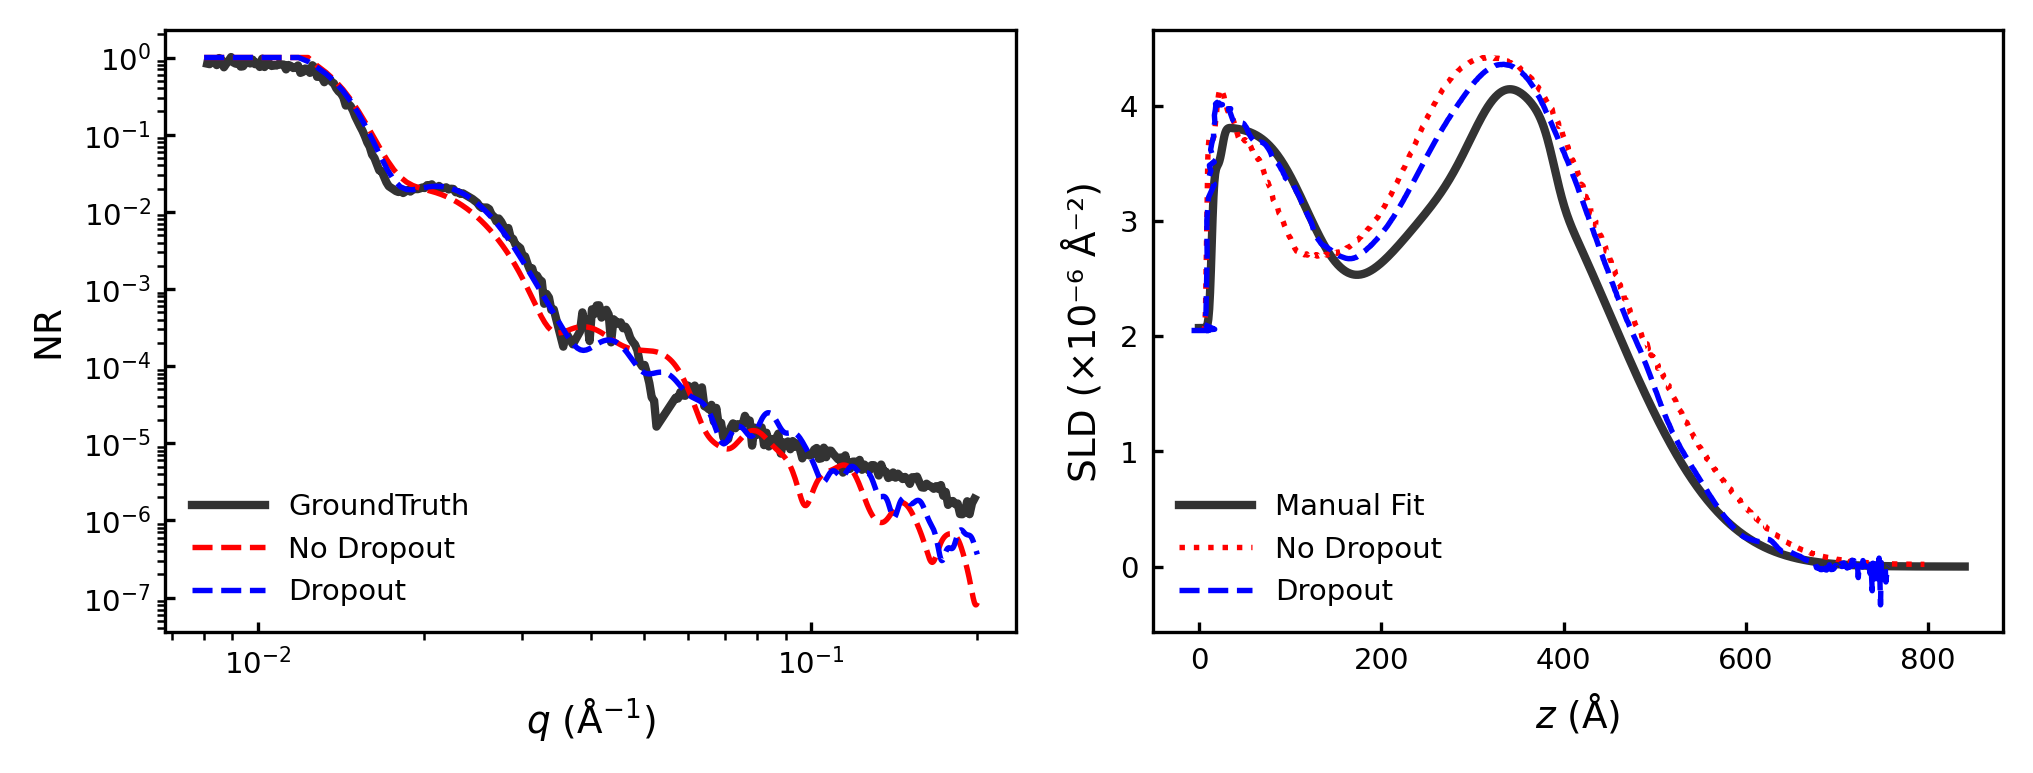

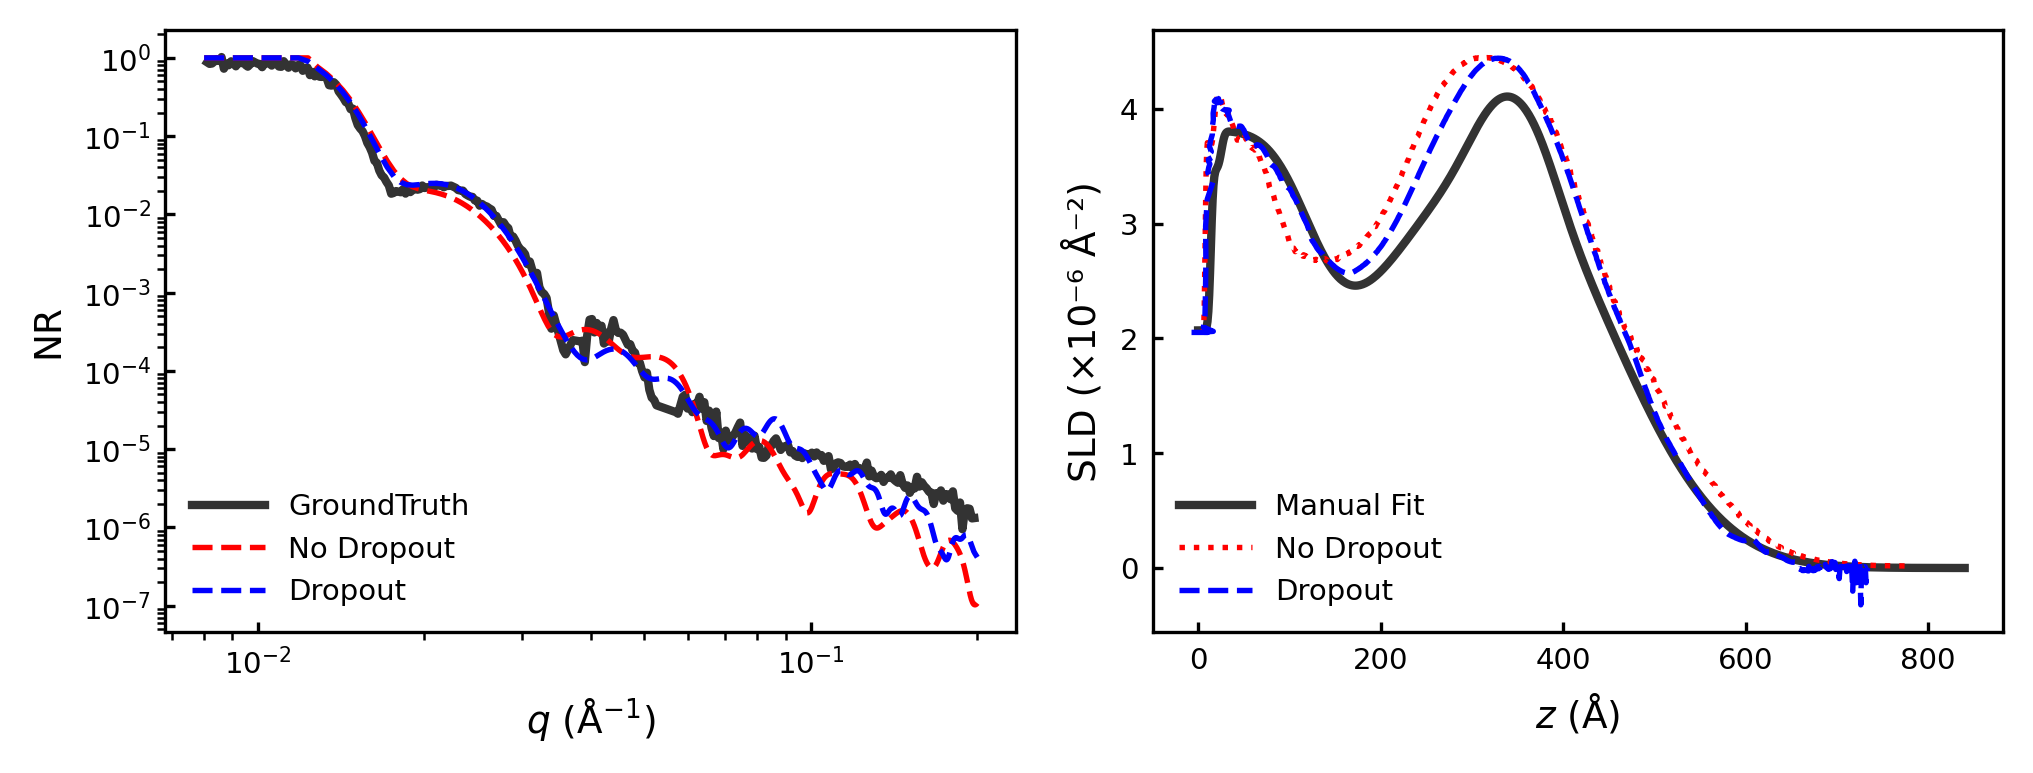

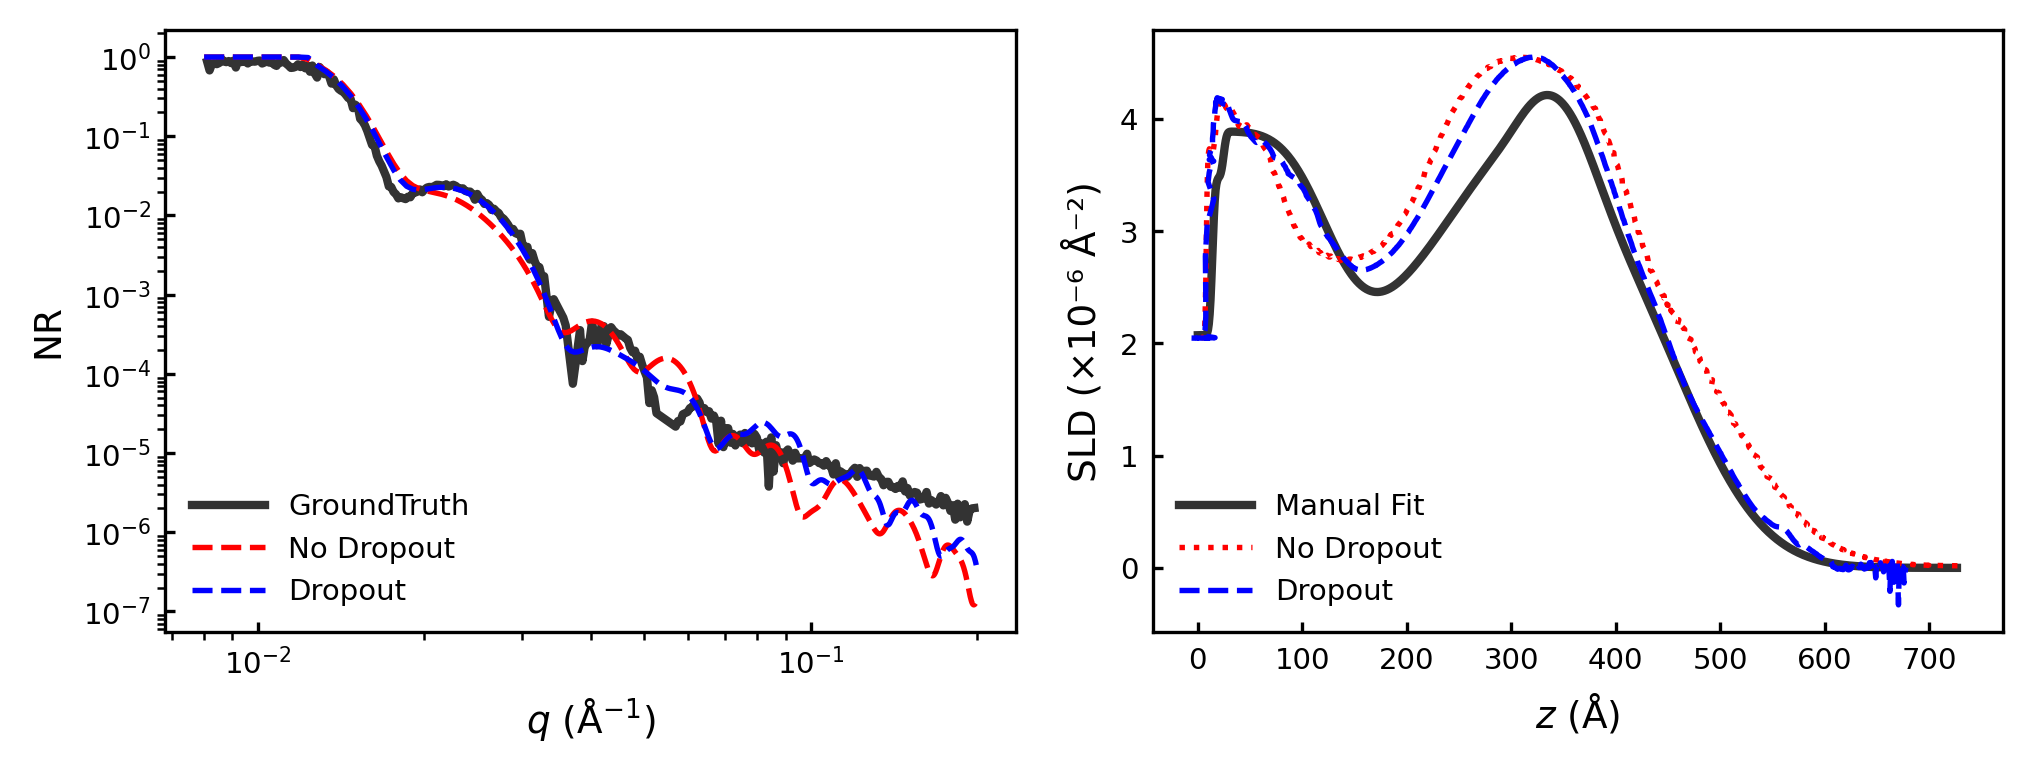

In [14]:
import numpy as np

# 1. Load the saved no dropout data arrays for comparison
no_dropout_path_pred = "data/curves/y_pred_batch_no_dropout_150k.npy"
no_dropout_path_nr   = "data/curves/computed_nr_batch_no_dropout_150k.npy"

no_dropout_exists = os.path.exists(no_dropout_path_pred) and os.path.exists(no_dropout_path_nr)

y_pred_no_dropout      = np.load(no_dropout_path_pred) if no_dropout_exists else None
computed_nr_no_dropout = np.load(no_dropout_path_nr)   if no_dropout_exists else None


# 2. Iterate through the batch and plot
for i in range(test_batch):
    # 3. Call the updated plotting function with all 6 datasets
    fig = plot_experiment_results(
        expt_nr_data=nr_batch[i],                          # GroundTruth NR
        expt_sld_data=true_sld[i],                         # GroundTruth SLD
        
        computed_nr_data=computed_nr_no_dropout[i],        # No Dropout NR or None (Loaded)
        computed_nr_dropout_data=computed_nr[i],           # Dropout NR
        predicted_sld_data=y_pred_no_dropout[i],           # No Dropout SLD or None (Loaded) 
        predicted_sld_dropout_data=y_pred[i]               # Dropout SLD
    )

## R² Score — Examine the Results

Align data array x to messure y difference for R² score

In [15]:
def compute_r2(y_true, y_pred):
    """Calculates the standard R-squared score."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0: return 0.0
    return 1 - (ss_res / ss_tot)

import numpy as np

def align_arrays(true_arr, pred_arr):
    """
    Forces pred_arr to use the exact same x-coordinates as true_arr.
    Both arrays must be shape (2, N).
    Row 0 is x (depth/q), Row 1 is y (SLD/reflectivity).
    """
    # 1. Grab the x-grid you want to snap to (from the true data)
    x_true = true_arr[0]
    
    # 2. Grab the x and y data from your prediction
    x_pred = pred_arr[0]
    y_pred = pred_arr[1]
    
    # 3. Interpolate the predicted y-values onto the true x-grid
    # Note: np.interp requires the source x-coordinates (x_pred) to be in increasing order!
    y_pred_aligned = np.interp(x_true, x_pred, y_pred)
    
    # 4. Stack them back together into a new (2, 900) array
    aligned_pred_arr = np.vstack((x_true, y_pred_aligned))
    
    return aligned_pred_arr


### Recheck aligned plot

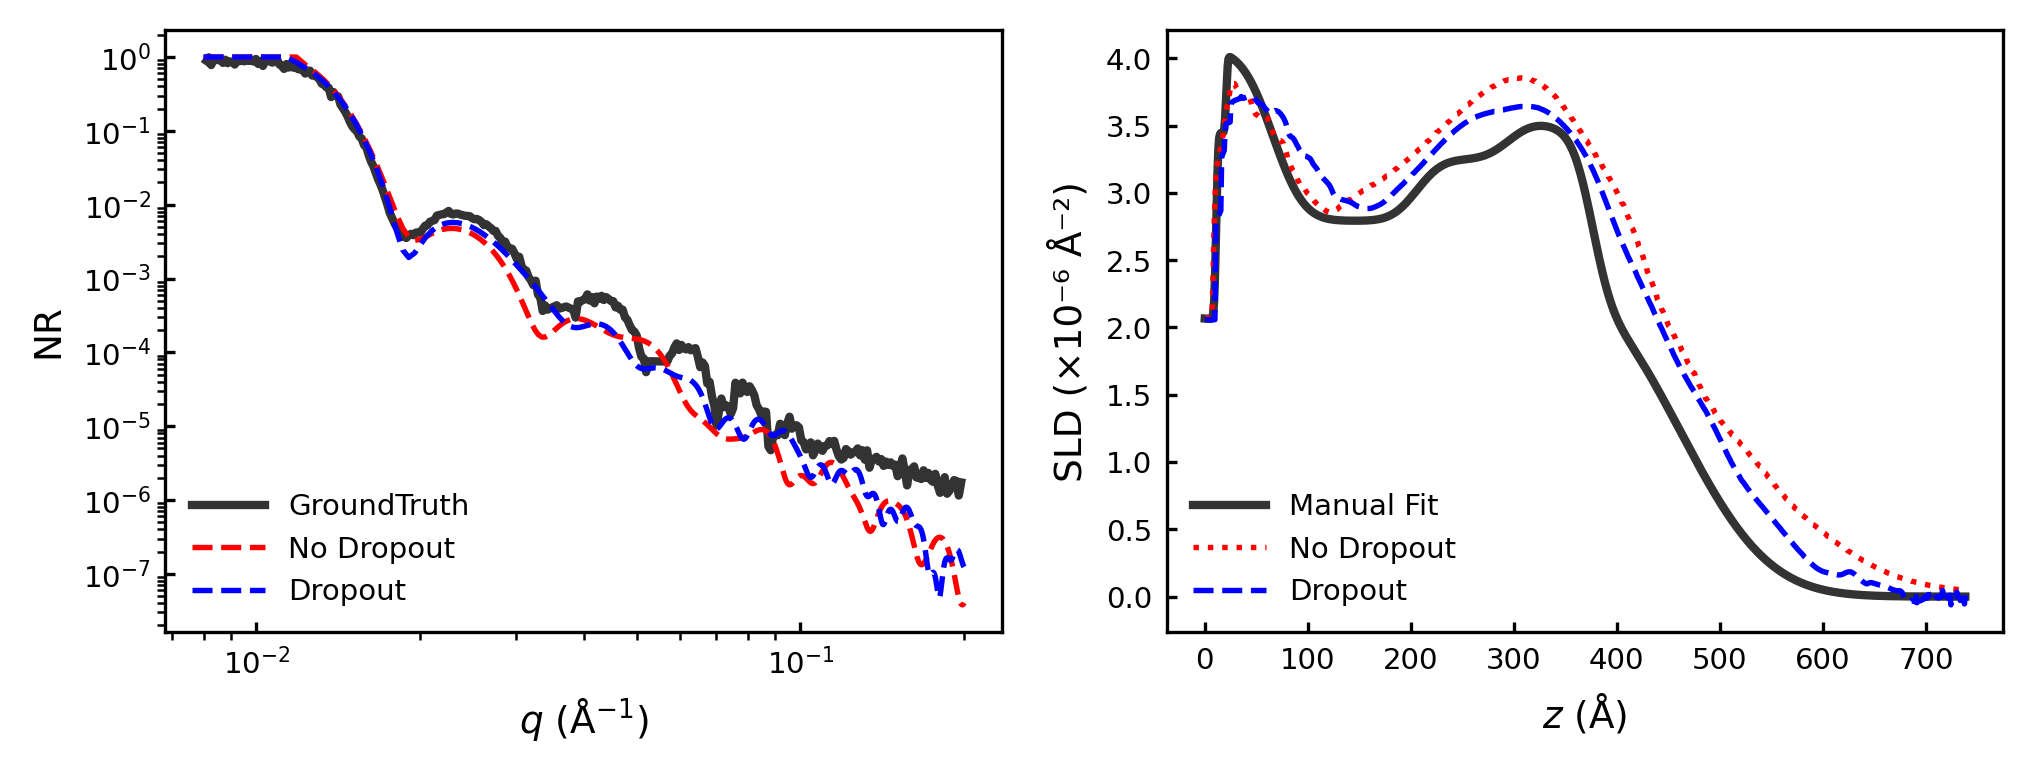

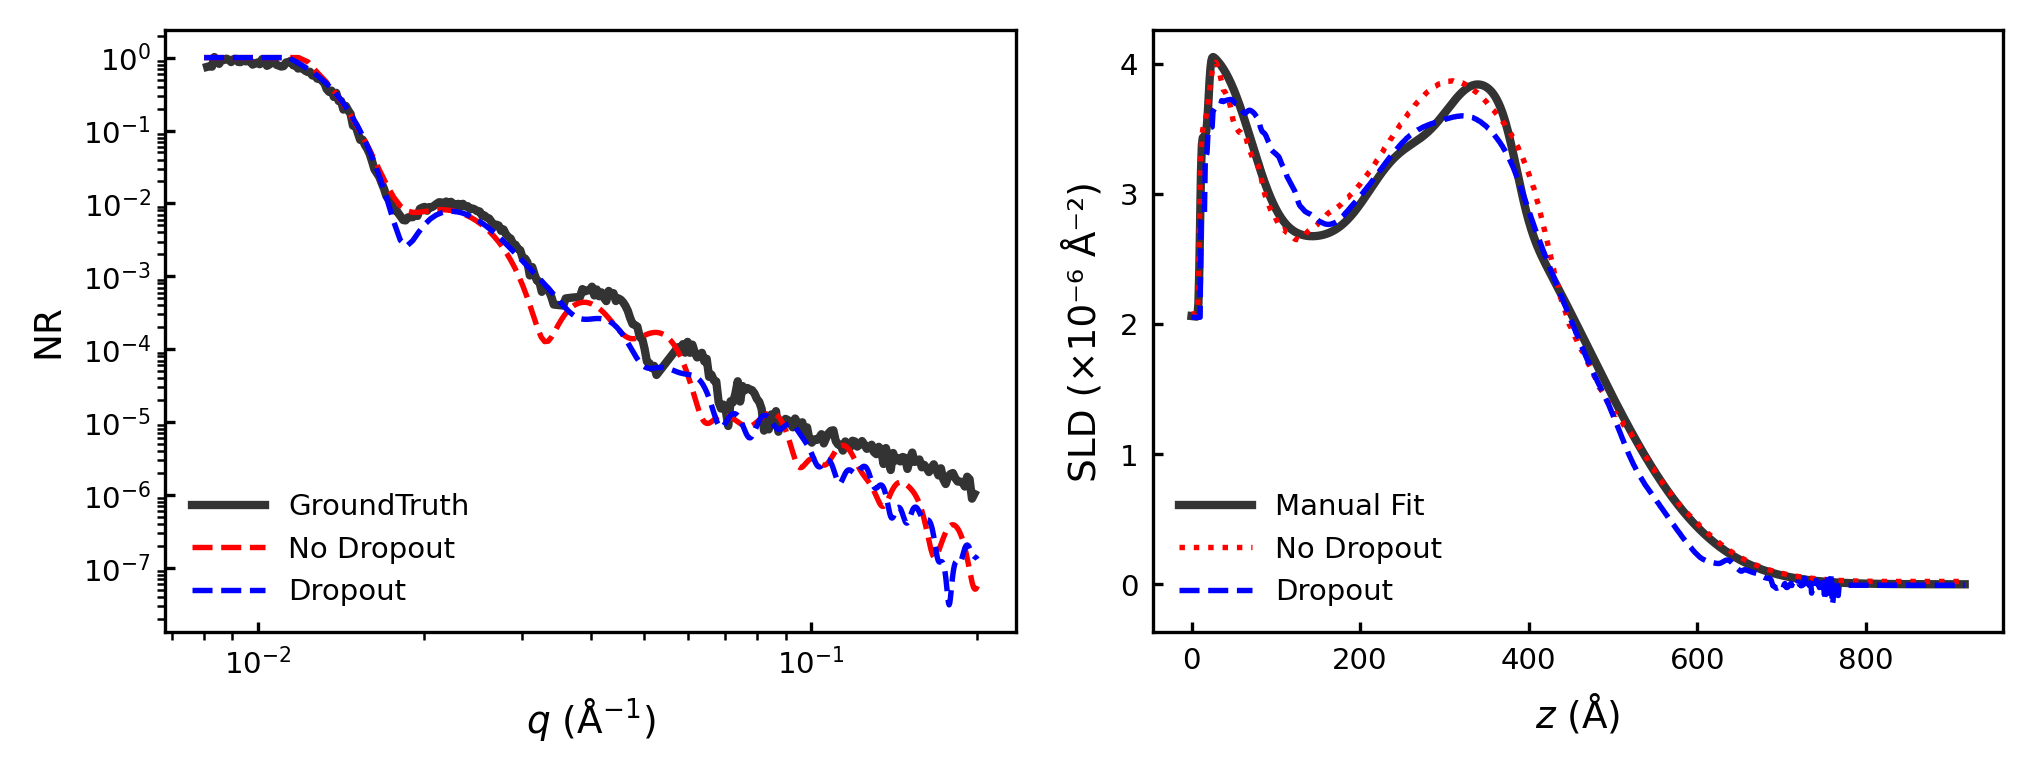

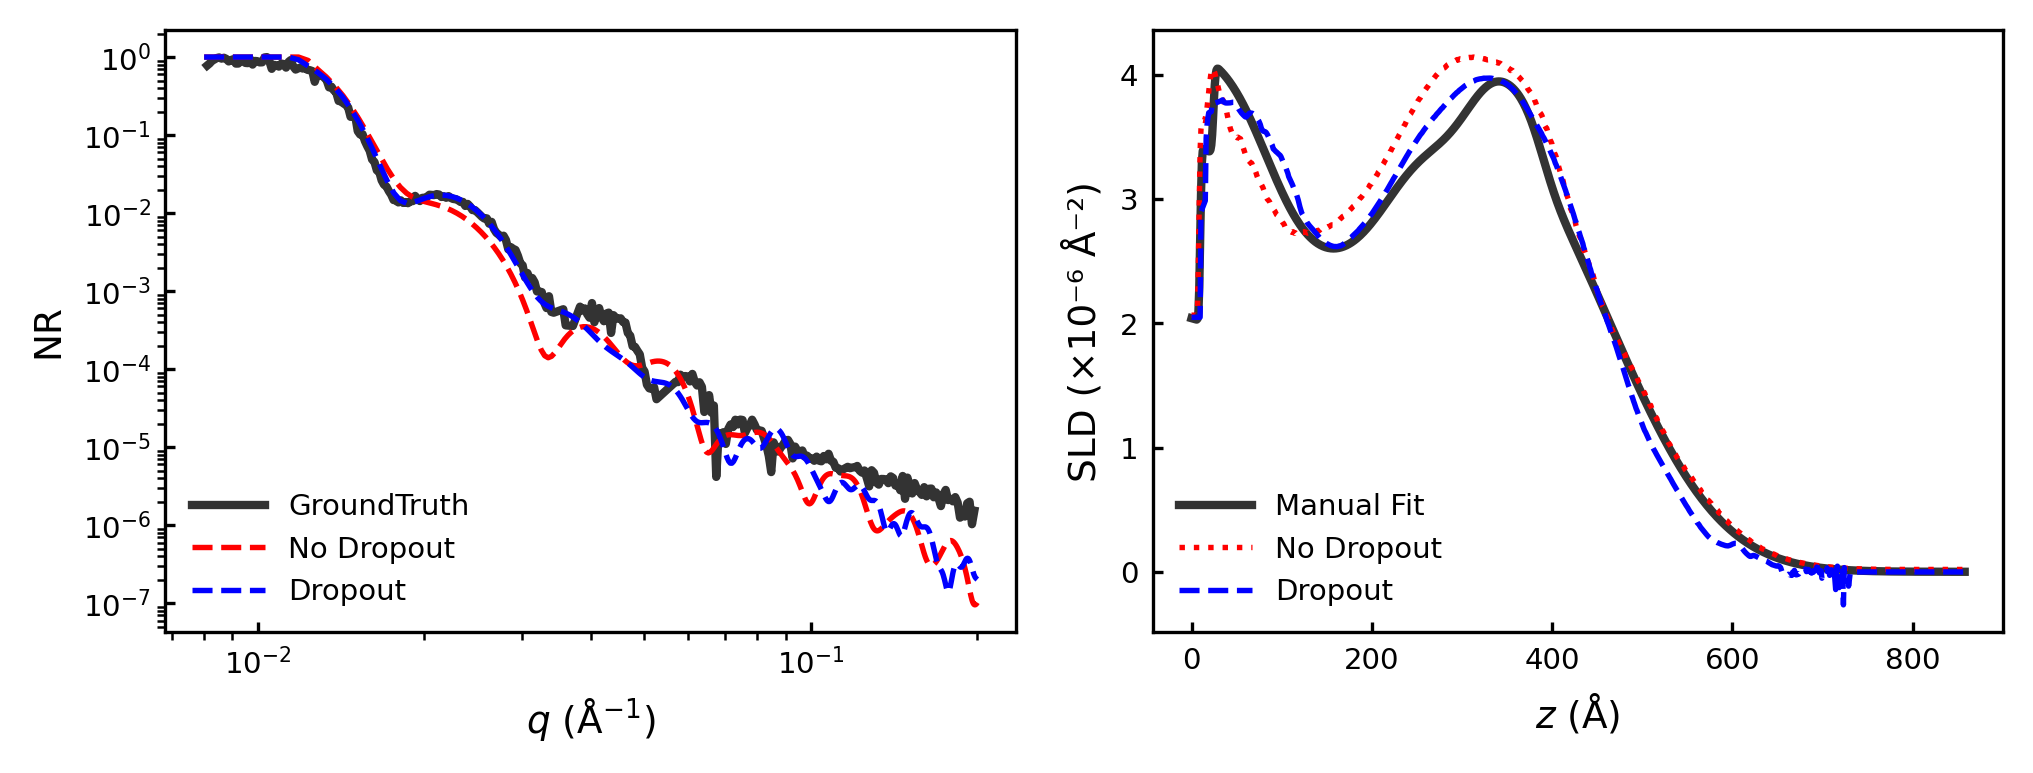

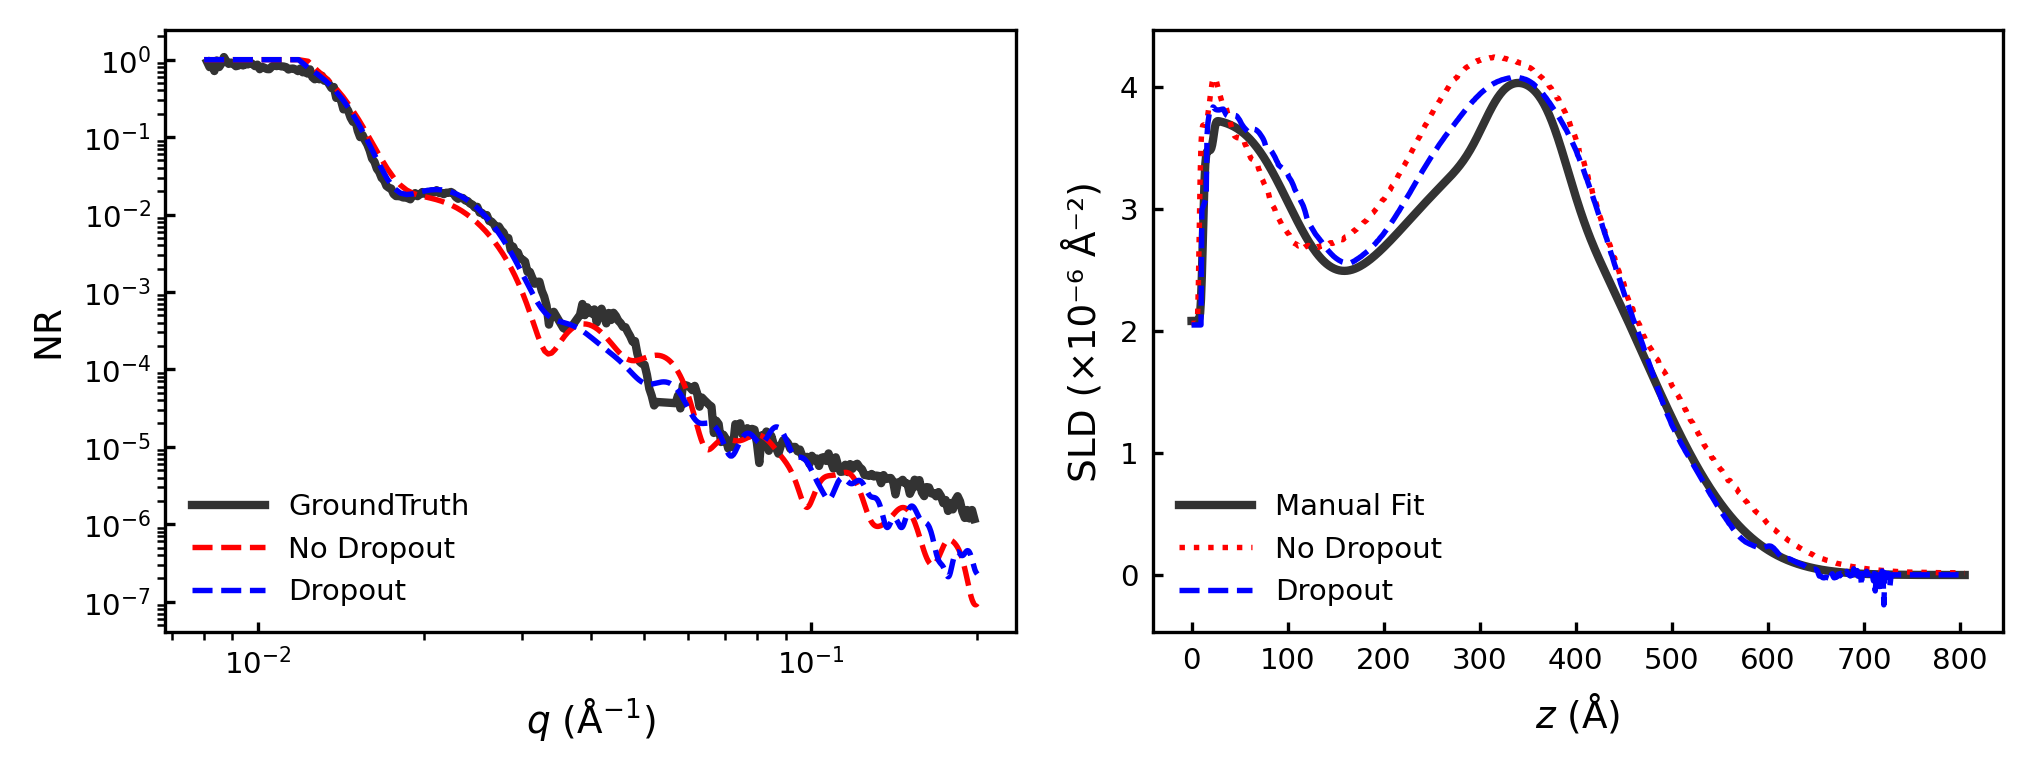

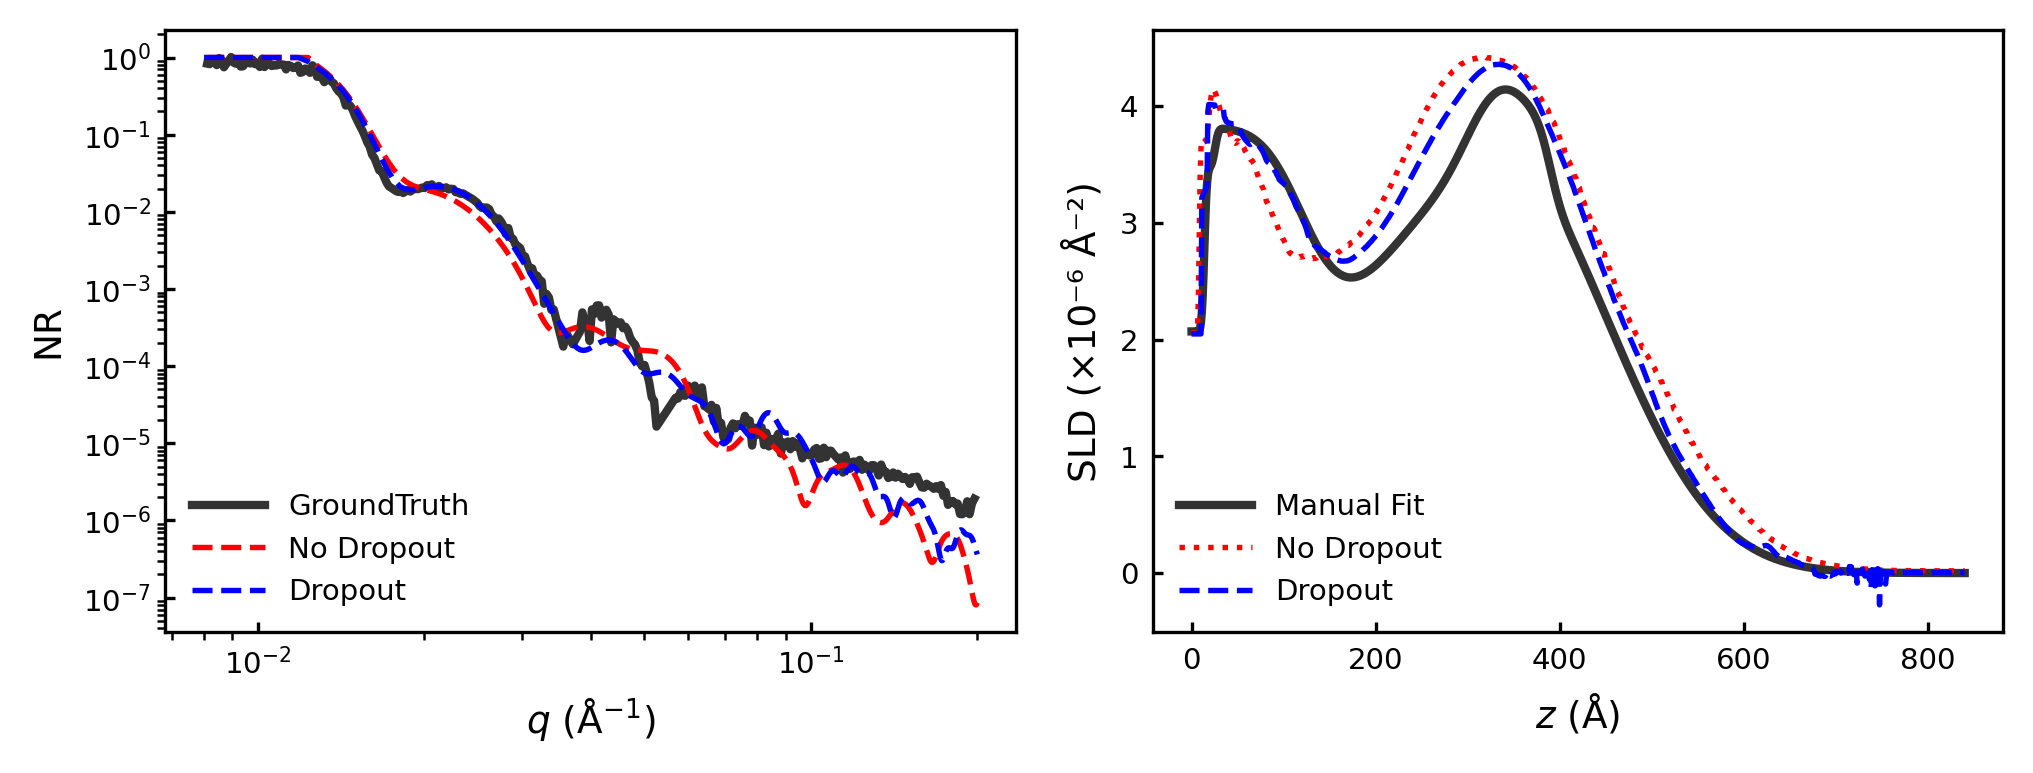

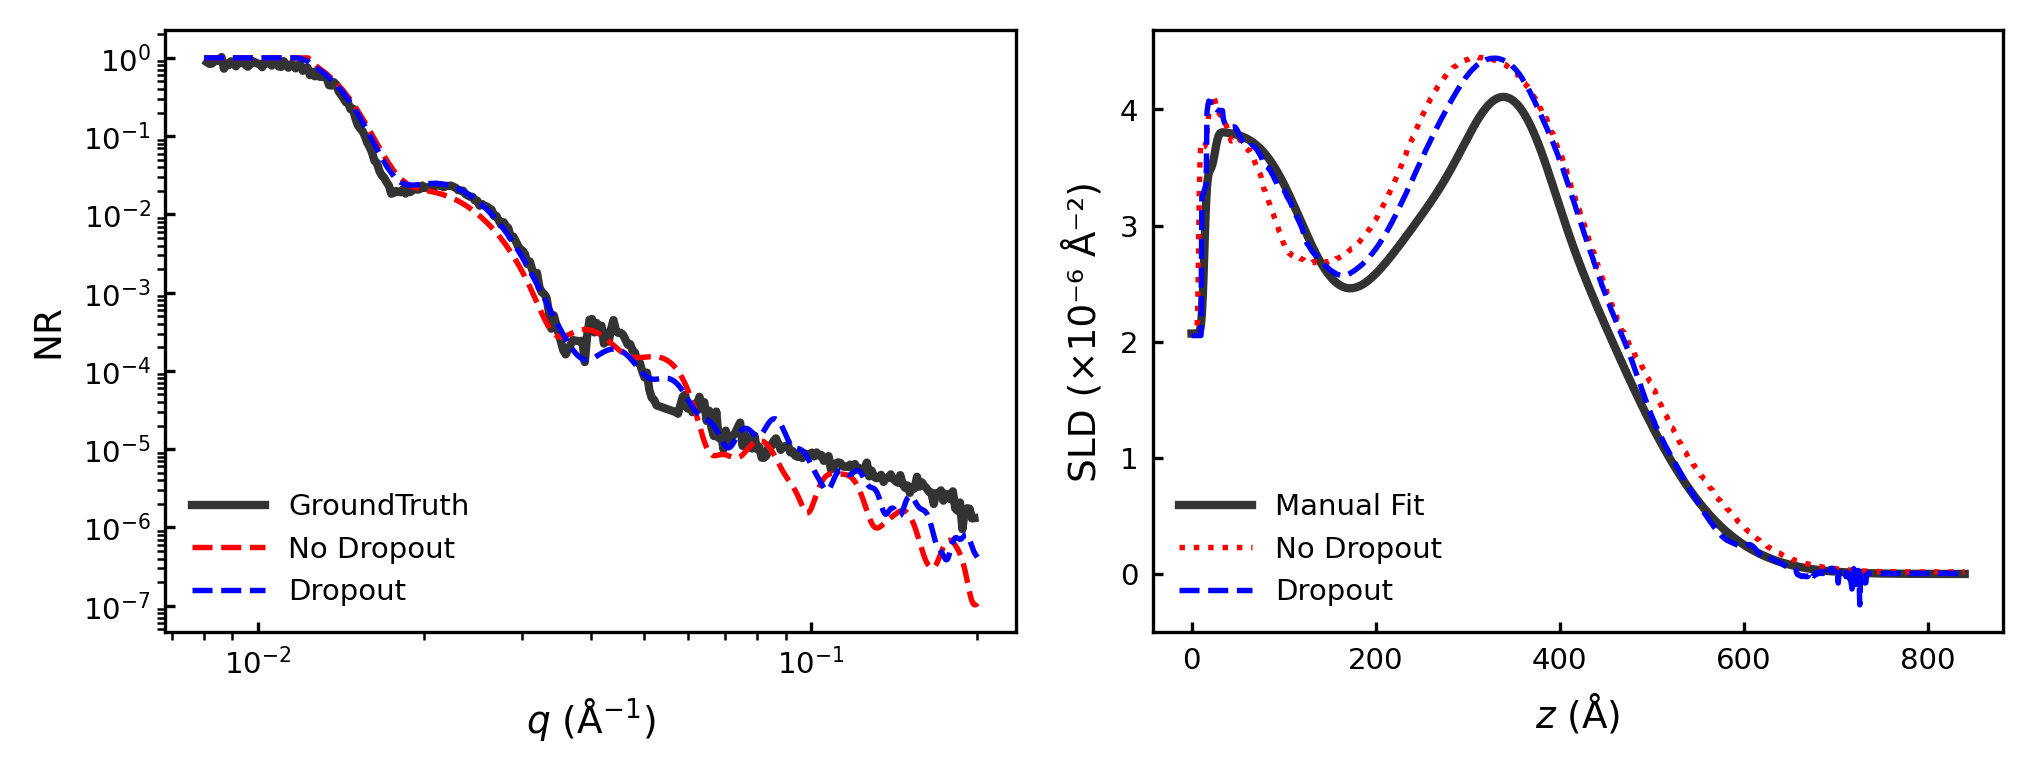

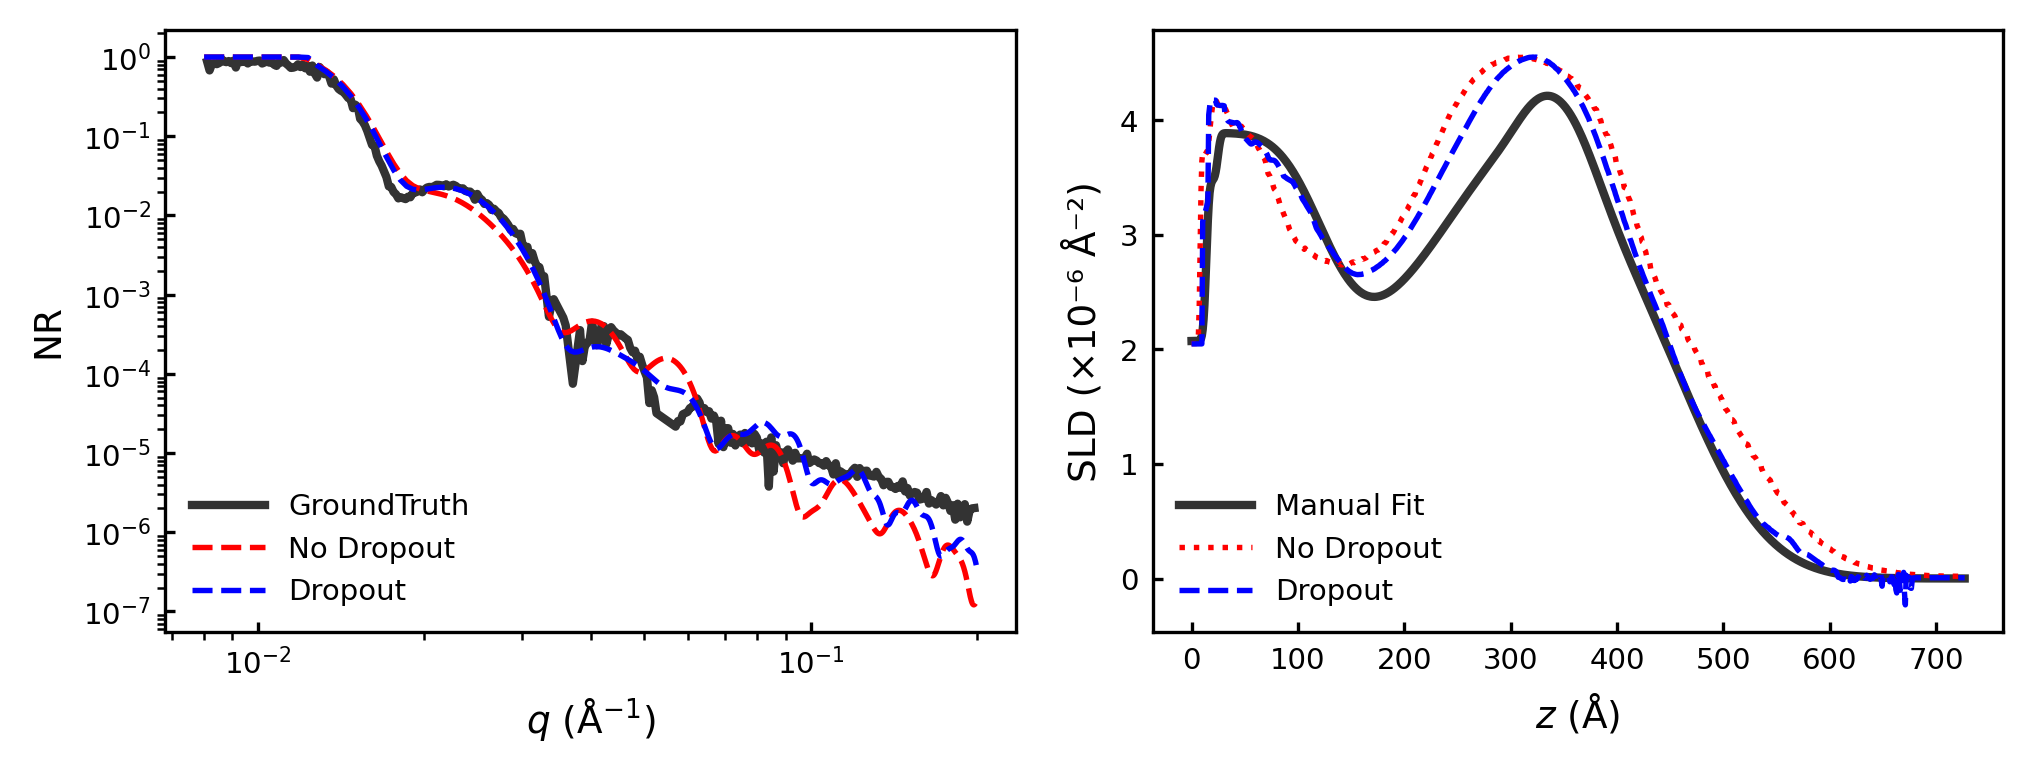

In [16]:
# # 2. Iterate through the batch and plot
# for i in range(test_batch):
# 
#     aligned_y_pred = align_arrays(true_sld[i],y_pred[i])
#     aligned_y_pred_no_dropout = align_arrays(true_sld[i],y_pred_no_dropout[i])
#     
#     # 3. Call the updated plotting function with all 6 datasets
#     fig = plot_experiment_results(
#         expt_nr_data=nr_batch[i],                          # GroundTruth NR
#         expt_sld_data=true_sld[i],                         # GroundTruth SLD
#         
#         computed_nr_data=computed_nr_no_dropout[i],                   # No Dropout NR
#         computed_nr_dropout_data=computed_nr[i],   # Dropout NR (Loaded) 
#         predicted_sld_data=aligned_y_pred_no_dropout,                      # No Dropout SLD
#         predicted_sld_dropout_data=aligned_y_pred       # Dropout SLD (Loaded)
#         
#         # computed_nr_dropout_data=computed_nr[i],                   # No Dropout NR
#         # predicted_sld_dropout_data=y_pred[i],                      # No Dropout SLD
#     )

In [18]:
import numpy as np

# 1. Print the table header
print(f"{'Sample ID':<12} | {'R² (SLD No Dropout)':<18} | {'R² (SLD With Dropout)':<18}")
print("-" * 55)

# 2. Initialize lists to calculate the average later
r2_no_dropout_list = []
r2_dropout_list = []

# 3. Iterate through the batch
for i in range(test_batch):

    # Align the x-grids
    aligned_y_pred = align_arrays(true_sld[i], y_pred[i])
    aligned_y_pred_no_dropout = align_arrays(true_sld[i], y_pred_no_dropout[i])
    
    # Calculate R2 scores using ONLY the y-values (index 1)
    # true_sld[i][1] is the ground truth SLD
    r2_drop = compute_r2(true_sld[i][1], aligned_y_pred[1])
    r2_no_drop = compute_r2(true_sld[i][1], aligned_y_pred_no_dropout[1])
    
    # Save the scores to our lists
    r2_dropout_list.append(r2_drop)
    r2_no_dropout_list.append(r2_no_drop)
    
    # Print the row for this specific sample
    print(f"{i:<12} | {r2_no_drop:<18.4f} | {r2_drop:<18.4f}")

# 4. Print the final averages at the bottom
print("-" * 55)
mean_no_drop = np.mean(r2_no_dropout_list)
mean_drop = np.mean(r2_dropout_list)
print(f"{'AVERAGE':<12} | {mean_no_drop:<18.4f} | {mean_drop:<18.4f}")

Sample ID    | R² (SLD No Dropout) | R² (SLD With Dropout)
-------------------------------------------------------
0            | 0.9062             | 0.9543            
1            | 0.9929             | 0.9875            
2            | 0.9754             | 0.9899            
3            | 0.9505             | 0.9866            
4            | 0.9279             | 0.9751            
5            | 0.9348             | 0.9733            
6            | 0.8995             | 0.9662            
-------------------------------------------------------
AVERAGE      | 0.9410             | 0.9761            


In [19]:
import numpy as np

# 1. Print the table header for NR
print(f"{'Sample ID':<12} | {'R² (NR No Dropout)':<18} | {'R² (NR With Dropout)':<18}")
print("-" * 55)

# 2. Initialize lists to calculate the average later
r2_nr_no_dropout_list = []
r2_nr_dropout_list = []

# 3. Iterate through the batch
for i in range(test_batch):

    # Align the computed NR curves to the experimental NR x-grid
    aligned_computed_nr = align_arrays(nr_batch[i], computed_nr[i])
    aligned_computed_nr_no_dropout = align_arrays(nr_batch[i], computed_nr_no_dropout[i])
    
    # Calculate R2 scores using ONLY the y-values (index 1)
    # nr_batch[i][1] is the ground truth Reflectivity
    r2_nr_drop = compute_r2(nr_batch[i][1], aligned_computed_nr[1])
    r2_nr_no_drop = compute_r2(nr_batch[i][1], aligned_computed_nr_no_dropout[1])
    
    # Save the scores to our lists
    r2_nr_dropout_list.append(r2_nr_drop)
    r2_nr_no_dropout_list.append(r2_nr_no_drop)
    
    # Print the row for this specific sample
    print(f"{i:<12} | {r2_nr_no_drop:<18.4f} | {r2_nr_drop:<18.4f}")

# 4. Print the final averages at the bottom
print("-" * 55)
mean_nr_no_drop = np.mean(r2_nr_no_dropout_list)
mean_nr_drop = np.mean(r2_nr_dropout_list)
print(f"{'AVERAGE':<12} | {mean_nr_no_drop:<18.4f} | {mean_nr_drop:<18.4f}")

Sample ID    | R² (NR No Dropout) | R² (NR With Dropout)
-------------------------------------------------------
0            | 0.9522             | 0.9647            
1            | 0.9490             | 0.9652            
2            | 0.9485             | 0.9621            
3            | 0.9350             | 0.9477            
4            | 0.9235             | 0.9344            
5            | 0.9362             | 0.9462            
6            | 0.9434             | 0.9432            
-------------------------------------------------------
AVERAGE      | 0.9411             | 0.9519            
